## Introdução

O conjunto de dados de acidentes de trânsito, disponibilizado pela Polícia Rodoviária Federal (PRF) por meio do portal de dados abertos, reúne informações detalhadas sobre ocorrências em rodovias federais brasileiras. Esses dados são fundamentais para o monitoramento da segurança viária, planejamento de políticas públicas e análise de fatores associados à gravidade dos acidentes.

A natureza dessas informações permite a aplicação de métodos estatísticos adequados para variáveis binárias, com destaque para a Regressão Logística, que possibilita investigar fatores associados à ocorrência de óbitos em acidentes de trânsito.

## O Banco de Dados

O banco de dados contém registros de acidentes de trânsito ocorridos no estado da Paraíba, contemplando variáveis relacionadas às características dos envolvidos e às condições do acidente, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

Essa estrutura possibilita a análise da ocorrência de óbitos nos acidentes, bem como a investigação de padrões associados a fatores comportamentais, ambientais e circunstanciais presentes no momento do sinistro.

## Modelagem Estatística (Regressão Logística)

A variável resposta principal — ocorrência de óbito — é caracterizada como uma variável binária, assumindo valores 0 (não óbito) e 1 (óbito). Nesse contexto, a análise é conduzida por meio da Regressão Logística, permitindo modelar a relação entre a variável resposta e um conjunto de covariáveis explicativas, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia e estado físico.

A Regressão Logística permite estimar a probabilidade de ocorrência de óbito em função das variáveis explicativas, sendo amplamente utilizada em situações onde o interesse está na modelagem de eventos binários. Além disso, o modelo possibilita a interpretação dos efeitos das variáveis por meio das razões de chances (odds ratios), permitindo identificar fatores de maior risco associados aos acidentes fatais.

Essa abordagem possibilita a identificação de padrões relevantes e a avaliação do impacto das variáveis explicativas na probabilidade de ocorrência de óbitos, contribuindo para análises voltadas à segurança no trânsito.

In [28]:
import pandas as pd

df = pd.read_excel("acidentes2026_PB.xlsx")
df = df.dropna(how = 'all')
print(df.head())


     pesid data_inversa    dia_semana   horario   br      km  municipio  \
0  1663875   2026-01-01  quinta-feira  04:04:00  153   155.0  ARAGUAINA   
1  1663872   2026-01-01  quinta-feira  06:40:00  262   146.1  RIO CASCA   
2  1663827   2026-01-01  quinta-feira  06:58:00  101   193.0    BIGUACU   
3  1663828   2026-01-01  quinta-feira  07:05:00   60    23.0   BRASILIA   
4  1663884   2026-01-01  quinta-feira  06:17:00  163  1044.0     MATUPA   

                             causa_acidente                  tipo_acidente  \
0  Objeto estático sobre o leito carroçável                     Tombamento   
1                         Condutor Dormindo                Colisão frontal   
2  Reação tardia ou ineficiente do condutor  Colisão lateral mesmo sentido   
3  Reação tardia ou ineficiente do condutor               Colisão traseira   
4                    Transitar na contramão                Colisão frontal   

   Unnamed: 9  ... tipo_envolvido estado_fisico idade       sexo ilesos  \
0    

Os dados apresentados na tabela a seguir descrevem as variáveis disponíveis no conjunto de dados de acidentes de trânsito da Polícia Rodoviária Federal (PRF) para o estado da Paraíba. Cada variável possui uma classificação quanto ao tipo de dado, natureza e seu uso potencial em análises baseadas em modelos de classificação, como a Regressão Logística. Essas informações são essenciais para compreender a estrutura do banco de dados e orientar as análises subsequentes.

| Variável                   | Tipo de dado       | Natureza    | Característica                                                                                                                     |
| -------------------------- | ------------------ | ----------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| **sexo**                   | Categórica nominal | Qualitativa | Sexo do envolvido no acidente; pode indicar diferenças de comportamento e risco entre grupos                                       |
| **tipo_envolvido**         | Categórica nominal | Qualitativa | Classificação do envolvido (condutor, passageiro, pedestre, etc.); relevante para identificar perfis de maior vulnerabilidade      |
| **tipo_acidente**          | Categórica nominal | Qualitativa | Tipo de ocorrência (colisão, atropelamento, capotamento, etc.); variável fundamental para caracterização do evento                 |
| **condicao_metereologica** | Categórica nominal | Qualitativa | Condições climáticas no momento do acidente (chuva, céu claro, neblina, etc.); influencia a probabilidade de acidentes mais graves |
| **fase_dia**               | Categórica nominal | Qualitativa | Período do dia (dia, noite, amanhecer, entardecer); pode estar associado à visibilidade e risco de ocorrência                      |
| **estado_fisico**          | Categórica nominal | Qualitativa | Condição física do envolvido após o acidente (ileso, ferido leve, grave, etc.); importante para caracterizar a severidade          |
| **classificacao_acidente** | Categórica nominal | Qualitativa | Classificação geral do acidente quanto à gravidade; pode ser utilizada em análises de classificação multiclasse                    |
| **morte**                  | Binária (0/1)      | Qualitativa | Indica ocorrência de óbito (1 = sim, 0 = não); variável resposta principal em modelos de Regressão Logística                       |

---


### Importância das Medidas Descritivas

As medidas descritivas são utilizadas para caracterizar a estrutura das variáveis do estudo. No presente caso, as variáveis são predominantemente categóricas, como sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia, estado físico e classificação do acidente. Essas variáveis são descritas por meio de frequências absolutas e relativas, permitindo resumir sua distribuição no conjunto de dados.

A variável binária **morte** também é analisada por proporções, possibilitando avaliar a frequência de ocorrência de óbitos nos acidentes.

Essas descrições fornecem uma visão inicial dos padrões associados aos acidentes de trânsito, permitindo identificar perfis de maior risco e possíveis relações entre características dos envolvidos, condições do ambiente e a ocorrência de óbitos.


In [44]:
from sklearn.preprocessing import OrdinalEncoder

# Variáveis explicativas
cols_X = [
    "sexo",
    "tipo_envolvido",
    "condicao_metereologica",
    "fase_dia",
    "estado_fisico",
    "tracado_via",
    "tipo_pista",
    "classificacao_acidente"
]

# Variável resposta
col_y = "mortos"

# Criar base
df_modelo = df[cols_X + [col_y]].copy()

# Separar X
X = df_modelo[cols_X]

# Aplicar encoding (em TODAS categóricas)
encoder = OrdinalEncoder()
X = encoder.fit_transform(X)

# Converter de volta para DataFrame
import pandas as pd
X = pd.DataFrame(X, columns=cols_X)

# Atualizar no df_modelo
df_modelo[cols_X] = X

# Remover NA
df_modelo = df_modelo.dropna()

# Visualização
df_modelo.head()

,sexo,tipo_envolvido,condicao_metereologica,fase_dia,estado_fisico,tracado_via,tipo_pista,classificacao_acidente,mortos
1,2.0,1.0,1.0,3.0,0.0,99.0,2.0,1.0,0
2,2.0,1.0,5.0,0.0,0.0,17.0,0.0,1.0,0
3,2.0,1.0,1.0,3.0,0.0,10.0,0.0,1.0,0
4,2.0,1.0,6.0,0.0,0.0,99.0,2.0,1.0,0
5,2.0,1.0,1.0,3.0,2.0,38.0,0.0,1.0,0


### Relações lineares entre variáveis numéricas
 A matriz de correlação de Spearman entre as variáveis numéricas do dataset. O objetivo é identificar relações lineares fortes que possam informar próximas etapas (e.g., seleção de variáveis, multicolinearidade, ou insights de causa/efeito possível).

Pontos importantes:
- O coeficiente de Pearson varia de -1 a 1; 1 indica correlação positiva perfeita, -1 correlação negativa perfeita, e 0 nenhuma correlação linear.
- Correlação não implica causalidade: use estes resultados apenas como sinalizadores.
- Atenção a colinearidade: variáveis fortemente correlacionadas podem distorcer modelos que supõem independência entre variáveis (e.g., regressão).

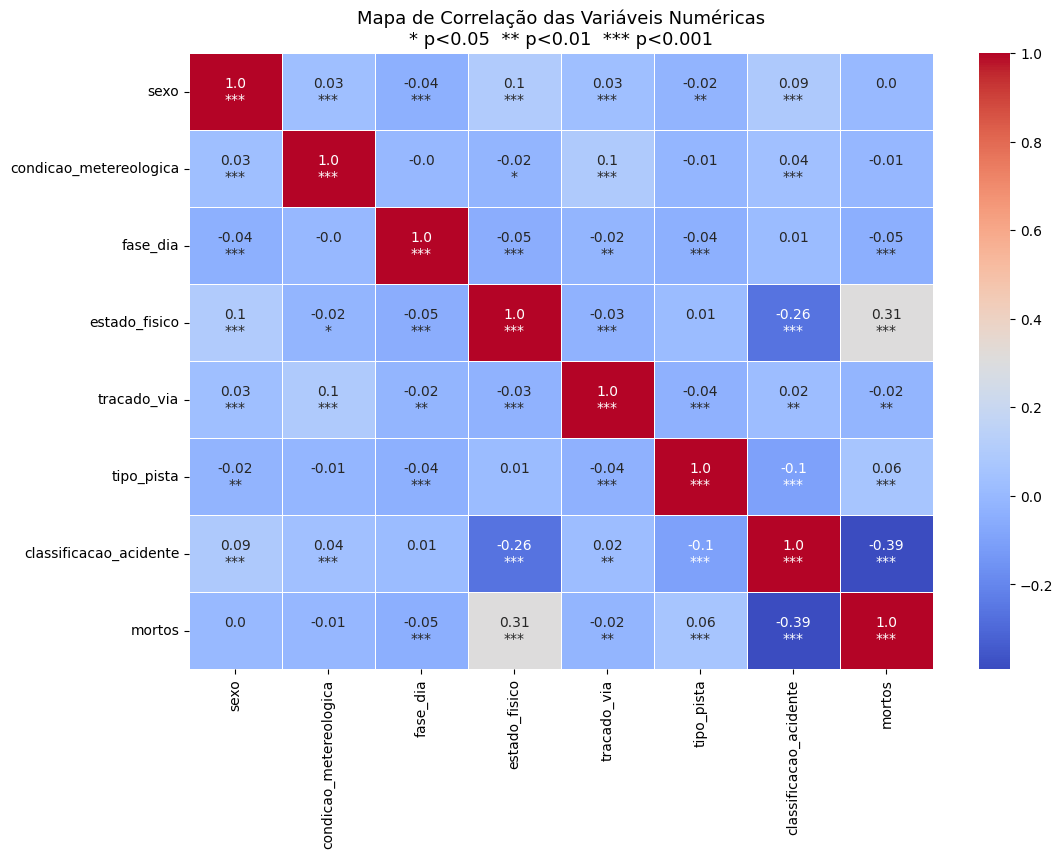

In [37]:
from scipy.stats import spearmanr
import numpy as np

# Calcula correlação e p-valores
corr = df_modelo.corr(numeric_only=True, method="kendall")
df_num = df_modelo.select_dtypes(include="number")
pval = pd.DataFrame(
    spearmanr(df_num, nan_policy="omit").pvalue,
    columns=corr.columns, index=corr.index
)

# Cria anotações com asteriscos
def significancia(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""

annot = corr.round(2).astype(str) + "\n" + pval.map(significancia)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=annot, cmap='coolwarm', fmt='', linewidths=0.5)
plt.title("Mapa de Correlação das Variáveis Numéricas\n* p<0.05  ** p<0.01  *** p<0.001", fontsize=13)
plt.show()

Diante das variáveis selecionadas, optou-se por prosseguir as análises considerando apenas as variáveis disponíveis no banco de dados de acidentes de trânsito, sem a necessidade de exclusão por multicolinearidade relevante.

Entretanto, os resultados do modelo de Regressão Logística indicaram que nenhuma das variáveis explicativas — sexo, tipo de envolvido, tipo de acidente, condição meteorológica, fase do dia, estado físico e classificação do acidente — apresentou associação estatisticamente significativa com a variável resposta morte, ao nível de significância adotado.

Esse resultado sugere que, com base nas variáveis consideradas, não foi possível identificar fatores com efeito estatisticamente relevante sobre a ocorrência de óbitos, indicando a possível necessidade de inclusão de novas variáveis ou abordagens alternativas para melhor explicação do fenômeno.

O **Variance Inflation Factor (VIF)** é uma medida utilizada em modelos de regressão para avaliar a presença de multicolinearidade entre as variáveis explicativas. Ele quantifica o quanto a variância do estimador de um coeficiente de regressão está aumentada devido à correlação linear entre os preditores. VIF próximos de 1 indicam baixa correlação entre os preditores, enquanto valores elevados sugerem multicolinearidade. Na prática, valores acima de 5 costumam ser considerados indicativos de multicolinearidade relevante, podendo aumentar os erros padrão dos coeficientes e dificultar a interpretação dos efeitos das variáveis no modelo.

In [45]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_modelo[cols_X]
X = sm.add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variável"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) 
                 for i in range(X.shape[1])]

print(vif_df.sort_values("VIF", ascending=False))


                 Variável        VIF
0                   const  38.502663
5           estado_fisico   1.161840
8  classificacao_acidente   1.146356
2          tipo_envolvido   1.144113
1                    sexo   1.126041
7              tipo_pista   1.019019
6             tracado_via   1.016182
3  condicao_metereologica   1.011193
4                fase_dia   1.005653


In [48]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Garantir índice limpo
df_modelo = df_modelo.reset_index(drop=True)

# ⚠️ Ajuste da fórmula (sem vírgula/trailing '+')
formula = """
mortos ~
    tipo_envolvido +
    fase_dia +
    tracado_via +
    tipo_pista 
"""

# ⚠️ Modelo correto: Binomial (Logístico)
modelo = smf.glm(
    formula=formula,
    data=df_modelo,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

# Resultado
print(modelo.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 mortos   No. Observations:                15140
Model:                            GLM   Df Residuals:                    15135
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2126.0
Date:                ter, 17 mar 2026   Deviance:                       4251.9
Time:                        15:55:25   Pearson chi2:                 1.49e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.006221
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -3.4389      0.206    -16.

### Serão usadas três métricas:

* Resíduo studentizado/padronizado — mede o quão mal o modelo prevê aquela observação. Um valor grande indica que o ponto é um outlier na variável resposta (Y).
  
* Leverage (alavancagem) — mede o quão "extrema" é a observação em termos das variáveis preditoras (X). Um ponto com leverage alto fica longe do centro dos dados, tendo potencial para influenciar o modelo.
  
* Distância de Cook — combina os dois anteriores. Mede o impacto real daquela observação nos coeficientes estimados. É a métrica mais importante para identificar influênci

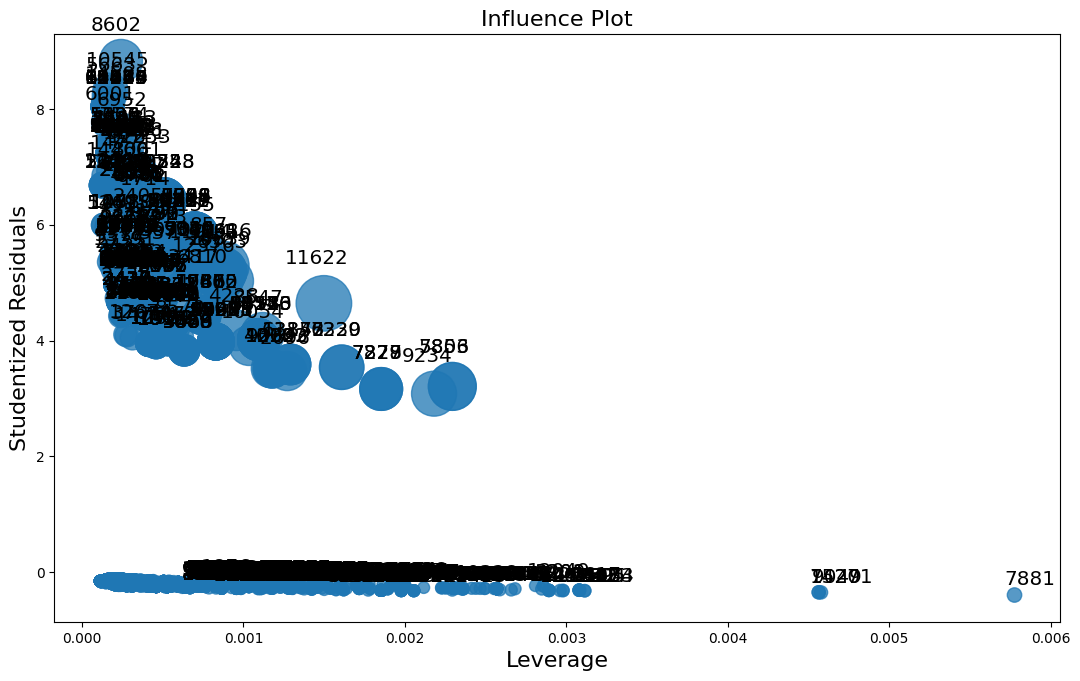

In [49]:
infl = modelo.get_influence(observed=True)
fig, ax = plt.subplots(figsize = (12,8))
fig = infl.plot_influence(ax = ax, size = 40, )
fig.tight_layout(pad=5.0, h_pad=10, w_pad=10)


Percebemos que há uma parcela de observações com leverage, ou seja, pontos de alavancagem relativamente altos. Além disso, observa-se uma grande concentração de valores entre 0 e 0,04, acompanhada de resíduos studentizados muito elevados. Isso já é um indício de que temos diversas observações que podem estar influenciando excessivamente o ajuste do modelo, prejudicando sua estabilidade e qualidade inferencial.

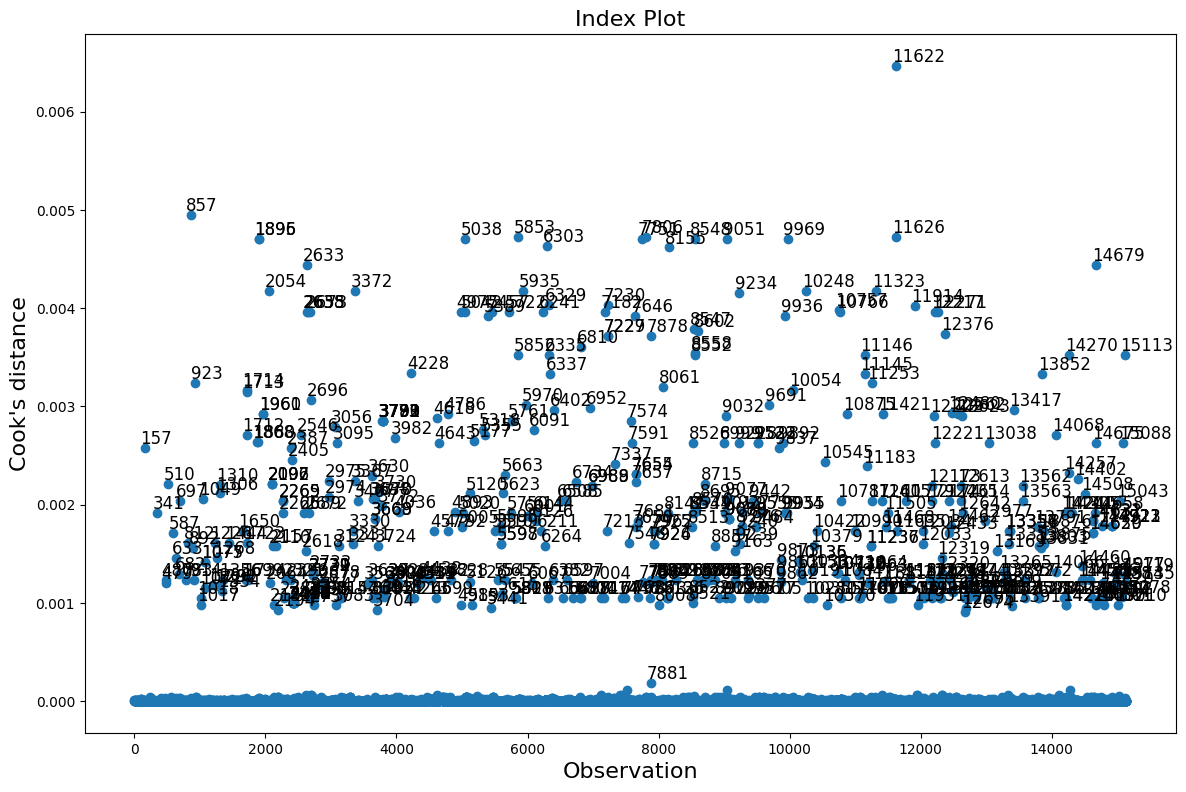

In [50]:
fig, ax = plt.subplots(figsize=(12,8))
fig = infl.plot_index(y_var="cooks", threshold=2 * infl.cooks_distance[0].mean(), ax = ax)
fig.tight_layout(pad=1.0)

Com o mesmo propósito de identificar observações excessivamente problemáticas, optou-se pela visualização da Distância de Cook. Por meio desse gráfico, é possível identificar claramente dois clusters de observações influentes que impactam de forma considerável a estimação dos parâmetros do modelo. Com base nessa análise, foram removidas apenas as observações que apresentaram simultaneamente uma Distância de Cook elevada e resíduos studentizados altos, por serem as que de fato comprometem a qualidade do ajuste.

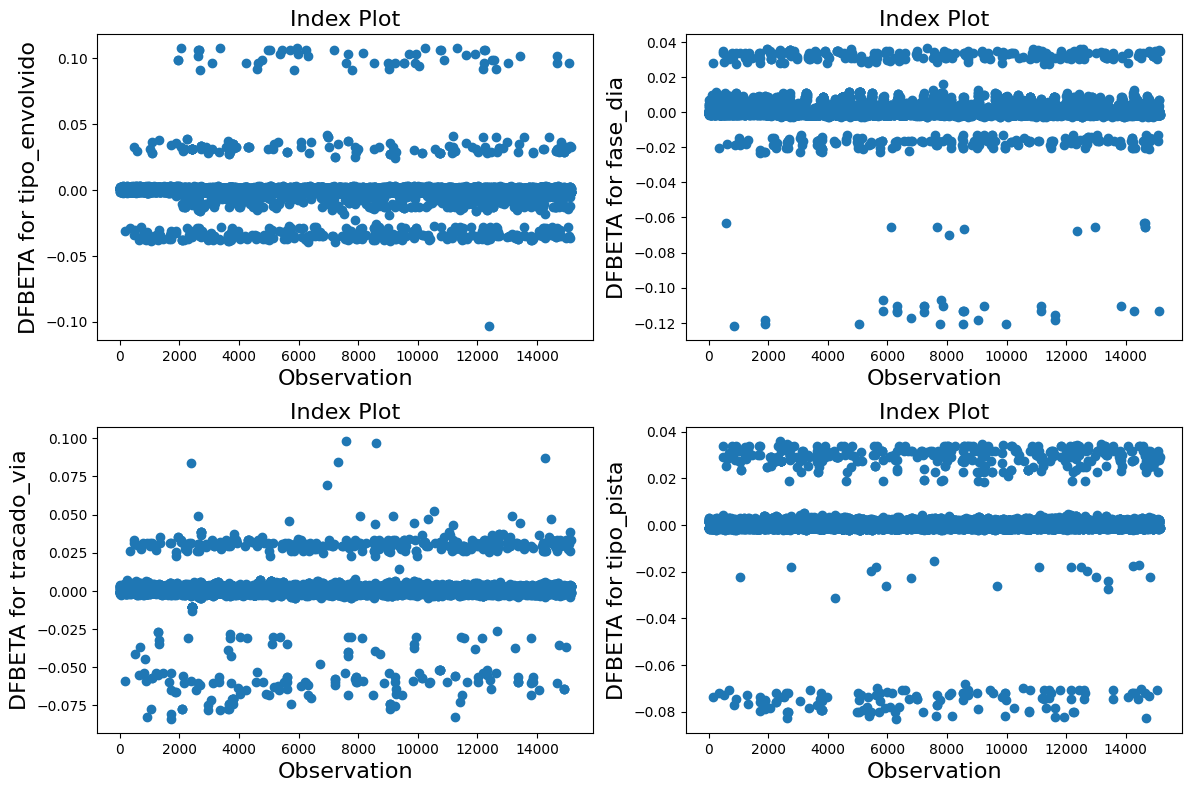

In [60]:
a = [1, 2, 3, 4]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes_flat = axes.flatten()  # transforma em [ax0, ax1, ax2, ax3, ax4, ax5]
for i, ax in zip(a, axes_flat):
    infl.plot_index(y_var="dfbeta", idx=i, threshold=0.5, ax=ax)  # passa UM subplot

# Apaga o subplot vazio
#axes_flat[-1].set_visible(False)

fig.tight_layout(pad=1.0)
plt.show()

In [ ]:
np.exp(modelo.params). round(3) 

Intercept                          7.012
pct_energia_renovaveis_primaria    0.967
densidade_populacional             0.999
co2_emissoes_tm_per_capita         1.000
dtype: float64

In [ ]:
#logit.params
from matplotlib.pylab import exp #ou
import numpy as np
exp(modelo.conf_int(alpha=0.05)).round(3)


,0,1
Intercept,6.636,7.410
pct_energia_renovaveis_primaria,0.963,0.971
densidade_populacional,0.999,1.000
co2_emissoes_tm_per_capita,1.000,1.000


### Por que utilizar a função `exp` para interpretar os intervalos de confiança?

No modelo de regressão Gamma com link log, os coeficientes estimados (coef) estão na escala logarítmica. Essa escala não é diretamente interpretável em termos da variável resposta original. Para interpretar os coeficientes de forma mais intuitiva, é necessário transformá-los de volta para a escala original, o que é feito aplicando a função exponencial (`exp`), obtendo assim a razão de médias (mean ratio) sobre a média esperada da intensidade energética.

* O fator multiplicativo para **pct_energia_renovaveis_primaria** é aproximadamente 0.78, com um intervalo de confiança de aproximadamente [0.76, 0.80]. Isso significa que, para cada aumento de 1 ponto percentual na participação de energia renovável primária, a média esperada da intensidade energética diminui em cerca de 22%, mantendo as outras variáveis constantes.

* O fator multiplicativo para **pib_per_capita** é aproximadamente 0.91, com um intervalo de confiança de aproximadamente [0.89, 0.94]. Isso significa que, para cada aumento de 1 unidade no PIB per capita, a média esperada da intensidade energética diminui em cerca de 9%, mantendo as outras variáveis constantes.

* O fator multiplicativo para **densidade_populacional** é aproximadamente 0.90, com um intervalo de confiança de aproximadamente [0.88, 0.92]. Isso significa que, para cada aumento unitário na densidade populacional, a média esperada da intensidade energética diminui em cerca de 10%, mantendo as outras variáveis constantes.

* O fator multiplicativo para **co2_emissoes_tm_per_capita** é aproximadamente 1.06, com um intervalo de confiança de aproximadamente [1.03, 1.09]. Isso indica que cada aumento unitário nas emissões de CO₂ per capita eleva a média esperada da intensidade energética em cerca de 6%, mantendo as outras variáveis constantes.